# Lab 6: Experiment Design Audit — Power, Selection, and Weighting
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 15 min Extension

---

**Format:** This lab contains **deliberately flawed code, underpowered experiments, and biased analyses**. Your job:
1. Run the code
2. Identify what is wrong (you are not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**AI in this lab:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion. This lab has no AI-assisted coding section: every line you add is yours, including the required "Write it yourself" function. The one AI use is the README prompt at the end, which asks for documentation, not code.

---

> ### What you write, and what you run
>
> **You write code:**
> - **Part 1, Steps 3 and 4:** three blanks in the power calculation.
> - **Part 3, Step 9:** four blanks: the IPW weights, and where they go.
> - **Write it yourself (required, after Part 3):** a `power_check()` function and one line that uses it, about five lines, in an empty cell. A check cell tells you when it is right. It is the one cell in this lab you write from nothing, and it is required.
> - **Extension (optional), Steps 11 and 12:** four blanks in Meng's identity.
>
> **You write, in text cells:** the diagnosis and interpretation answers: six in Part 1, four in Part 2, three in Part 3, and three in the Extension.
>
> **You run and read:** everything else. That is the PM's analysis, the simulated wellness-program and poll data, the propensity model and the charts. Read each cell before you run it: the questions ask about what it prints.

In [1]:
# Setup — run first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

## Part 1: Power Analysis — Is This Experiment Big Enough? (10 min)

### Scenario

A fintech company rolled out a new onboarding flow to **2% of users** (1,000 out of 50,000).
After 30 days, they measured the conversion rate:
- **Control group** (49,000 users): 5.0% conversion rate
- **Treatment group** (1,000 users): 5.8% conversion rate

The product manager claims: *"The new flow increased conversions by 0.8 percentage points!
That's a 16% relative lift — ship it!"*

**Your task:** Audit this experiment. Is the sample size sufficient to detect a 0.8pp effect?

**Reading the prints.** In an f-string, `{x:.3f}` shows three decimals, `{x:.1%}`
shows a percent, `{x:,}` adds thousands separators, and `{x:>8,.0f}` right-aligns
the number in 8 characters. A number written `49_000` is 49000: the underscore is
only there to help you read it.

In [2]:
# THE PM'S ANALYSIS — run as-is, then audit its conclusion
# Step 2: The product manager's analysis

n_control = 49_000
n_treatment = 1_000
p_control = 0.050
p_treatment = 0.058

# Two-proportion z-test: under "no effect" both groups share one pooled rate
p_pooled = (p_control * n_control + p_treatment * n_treatment) / (n_control + n_treatment)
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_treatment))
z_stat = (p_treatment - p_control) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))     # two-sided: both tails count

print("=== Product Manager's Analysis ===")
print(f"Observed lift: {p_treatment - p_control:.3f} ({(p_treatment - p_control)/p_control:.1%} relative)")
print(f"Z-statistic: {z_stat:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"\nConclusion: p = {p_value:.4f} > 0.05 — NOT statistically significant.")
print("But the PM says: 'The effect is real, we just need to be less conservative.'")

=== Product Manager's Analysis ===
Observed lift: 0.008 (16.0% relative)
Z-statistic: 1.147
P-value: 0.2512

Conclusion: p = 0.2512 > 0.05 — NOT statistically significant.
But the PM says: 'The effect is real, we just need to be less conservative.'


### YOUR DIAGNOSIS

Is the PM right? Or was this experiment doomed from the start?

**Before looking at the power calculation below, answer:**

1. The treatment group has only 1,000 users (2% of traffic). Is this a design choice or a mistake?
2. What is the Minimum Detectable Effect (MDE) the PM is trying to detect?
3. What would you need to know to determine whether 1,000 is enough?

1. This seens to be a mistake, because it was not checked that you can make a claim based of this size of a treatment group.
2. The MDE is 0.8 percentage points- which would be a 16 percent lift
3. to determine if 1000 is enough you would need the baseline conversion rate, the minmum effect size worth detecting, the desired power and the signifigance level. Using all these you can figure out what size sample is needed.

### Step 3: How many users would the test need?

**Power** is the chance that a test detects an effect of a given size, if the
effect is real. The usual design target is 80% power at a 5% significance level.

A power calculation needs the effect in standard units. For two proportions that
unit is **Cohen's h**, $h = 2\arcsin\sqrt{p_2} - 2\arcsin\sqrt{p_1}$. The arcsine
puts a 0.8-point lift on a 5% base and on a 50% base on one common scale.

`TTestIndPower().solve_power()` takes four quantities: the effect size, the size
of group 1 (`nobs1`), `alpha` and `power`. Give it any three and it returns the
fourth. `ratio` is the size of group 2 divided by the size of group 1.

In [3]:
# YOUR TASK — fill in the blanks
# Step 3: Calculate required sample size for 80% power

cohens_h = 2 * np.arcsin(np.sqrt(p_treatment)) - 2 * np.arcsin(np.sqrt(p_control))
print(f"Cohen's h (effect size): {cohens_h:.4f}")

power_analysis = TTestIndPower()

# nobs1 is left out, so solve_power returns the n per group
required_n = power_analysis.solve_power(
    effect_size=cohens_h,
    alpha=0.05,
    power=0.80,
    ratio=1.0,                 # equal group sizes
    alternative='two-sided'
)

print(f"\nRequired sample size per group: {required_n:,.0f}")
print(f"Actual treatment group size:    {n_treatment:,}")
print(f"Shortfall: {required_n - n_treatment:,.0f} users")

Cohen's h (effect size): 0.0354

Required sample size per group: 12,514
Actual treatment group size:    1,000
Shortfall: 11,514 users


In [4]:
# YOUR TASK — fill in the blank
# Step 4: What power did the actual experiment have?

# power is left out this time, so solve_power returns it
actual_power = power_analysis.solve_power(
    effect_size=cohens_h,
    nobs1=n_treatment,
    alpha=0.05,
    ratio=n_control / n_treatment,     # control is 49 times the treatment group
    alternative='two-sided'
)

print(f"Actual power of this experiment: {actual_power:.1%}")
print(f"Required power:                  80.0%")

Actual power of this experiment: 19.8%
Required power:                  80.0%


**Verification checkpoint:** The actual power should be between 15% and 40%. If you get 80%+, check your inputs. (Measured: 12,514 users needed per group, and
an actual power of 19.8%.)

### Diagnosis Summary

1. **What went wrong with this experiment?**
2. **What should the PM have done differently?** (Name two specific changes.)
3. **Connection to Chapter 6:** Meng showed that a biased sample of 2.3M was worth only 400 random observations. Here an experiment that reached 50,000 users had only 20% power. Both failures stem from *design*, not size. Explain the parallel.

1. The experiment only had about 20% power which means it only had a one in five chance of actually detecting the effect if there really was one. The P value was 0.25 which does not mean the effect is zero, instead it is because the group size was too small to draw conclusions.
2. The PM should have calculated the power necessary before determining the size of the treatment group to actually hit the 80% power. The experiment also should have been split more evenly. Treatment was only 2% of the total sample size, if it was a larger percent, the experiment would have more power and be more accurate.
3. For both experiment designs, the failures came from the group designations and how the data was collected. They both have very low power because of how small the treatment group was in comparison so you cannot draw any real conclusions.

---

## Part 2: Diagnose Selection Bias in Observational Data (10 min)

### Scenario

A health policy researcher wants to estimate the effect of a **wellness program**
on employee healthcare costs. The program is voluntary — employees self-select
into participation. The researcher runs a simple comparison and concludes the
program *reduces* costs.

**Your task:** Identify the selection bias and determine its direction.

In [5]:
# GIVEN — run as-is
# Step 5: Simulate the wellness-program data

rng = np.random.default_rng(seed=RANDOM_STATE)
n = 5000

# Baseline health runs from 0 (poor) to 1 (excellent); beta(2, 5) leans toward poor
baseline_health = rng.beta(a=2, b=5, size=n)

# Each employee's chance of joining is an S-shaped (logistic) curve in baseline health
prob_join = 1 / (1 + np.exp(-5 * (baseline_health - 0.35)))
treatment = rng.random(n) < prob_join          # True = joined the program

# We simulate the data, so the program's true effect is known: it saves $500
true_effect = -500
costs = (
    15000                              # base cost
    - 8000 * baseline_health
    + true_effect * treatment          # True counts as 1, False as 0
    + rng.normal(0, 2000, size=n)      # noise
)

df = pd.DataFrame({
    'baseline_health': baseline_health,
    'treatment': treatment.astype(int),    # stored as 1/0
    'costs': costs
})

# .sum() of True/False counts the Trues and .mean() is their share; ~ flips True and False
print(f"Participants: {treatment.sum()} ({treatment.mean():.1%})")
print(f"Non-participants: {(~treatment).sum()} ({(~treatment).mean():.1%})")

Participants: 2111 (42.2%)
Non-participants: 2889 (57.8%)


In [6]:
# THE RESEARCHER'S ANALYSIS — run as-is
# Step 6: Naive comparison

# .loc[rows, column]: the costs of the rows where treatment is 1, then 0
mean_treated = df.loc[df['treatment'] == 1, 'costs'].mean()
mean_control = df.loc[df['treatment'] == 0, 'costs'].mean()
naive_effect = mean_treated - mean_control

print("=== Researcher's Naive Comparison ===")
print(f"Mean cost (participants):     ${mean_treated:,.0f}")
print(f"Mean cost (non-participants): ${mean_control:,.0f}")
print(f"Naive estimated effect:       ${naive_effect:,.0f}")
print(f"\nResearcher's conclusion: 'The wellness program saves ${abs(naive_effect):,.0f} per employee!'")
print(f"True effect: ${true_effect:,}")

=== Researcher's Naive Comparison ===
Mean cost (participants):     $11,725
Mean cost (non-participants): $13,121
Naive estimated effect:       $-1,396

Researcher's conclusion: 'The wellness program saves $1,396 per employee!'
True effect: $-500


### YOUR DIAGNOSIS

1. **What is the confounder?** (Name the variable that affects both treatment selection and outcome.)
2. **What is the direction of selection bias?** The naive estimate is $___. The true effect is -$500. Is the naive estimate biased upward or downward (in absolute magnitude)? Explain *why* using the confounder.
3. **Draw the DAG.** Describe the causal diagram with three nodes: `baseline_health`, `treatment`, `costs`. Which arrows exist? Which path creates the bias?
4. **Connection to Chapter 6:** This is selection bias — $\text{Cov}(R_i, Y_i) \neq 0$ from Meng's framework. Here, $R_i$ is the treatment indicator and $Y_i$ is potential outcomes. The self-selection mechanism creates a backdoor path. How does this connect to the Literary Digest example from the chapter?

**Verification checkpoint:** The naive effect should overestimate the true effect in absolute magnitude (i.e., show savings larger than $500). If your naive estimate is *smaller* than $500 in magnitude, check that the simulation ran correctly.

1. The cofounder is the baseline_health. It affects the likelihood of joining the wellness program and the healthcare costs.
2. There is a downward selection bias. The niave estimate is $-1396. This is because employees that are healthier are more likely to particiape in the experiment and will likely have lower healthcare costs in general.
3. The arrows are baseline_health → treatment, baseline_health → costs, and treatment → costs, with the backdoor path treatment ← baseline_health → costs creating the selection bias
4. This connects to the lierary digest poll because the wellness sample was not randomly chosen. The people that chose to participate sway the outcome making the estimate bias.

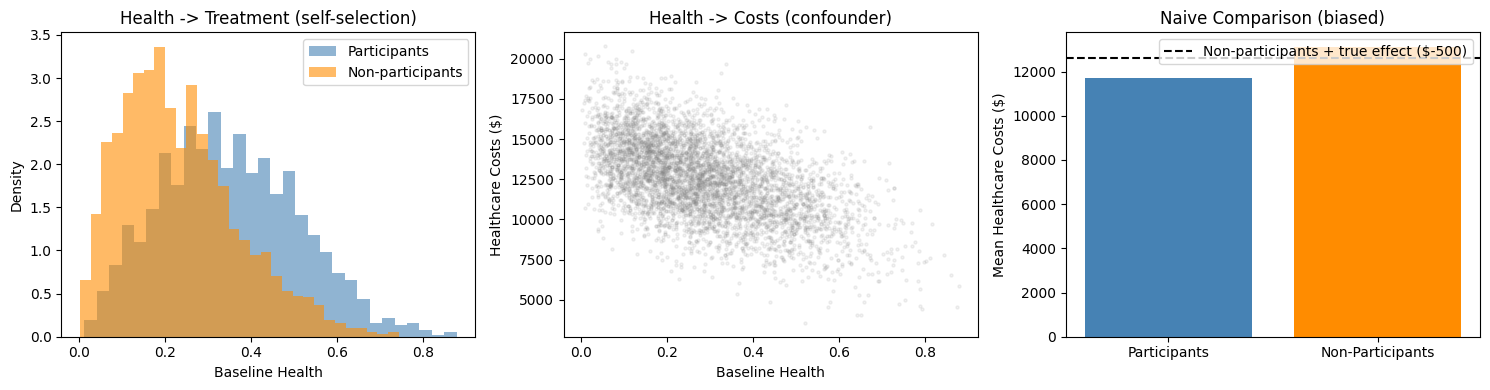

In [7]:
# GIVEN — run as-is
# Step 7: Visualize the confounding

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# density=True scales each histogram to area 1, so groups of different sizes compare
axes[0].hist(df.loc[df['treatment'] == 1, 'baseline_health'], bins=30, alpha=0.6,
             density=True, color='steelblue', label='Participants')
axes[0].hist(df.loc[df['treatment'] == 0, 'baseline_health'], bins=30, alpha=0.6,
             density=True, color='darkorange', label='Non-participants')
axes[0].set_xlabel('Baseline Health')
axes[0].set_ylabel('Density')
axes[0].set_title('Health -> Treatment (self-selection)')
axes[0].legend()

axes[1].scatter(df['baseline_health'], df['costs'], alpha=0.1, s=5, color='gray')
axes[1].set_xlabel('Baseline Health')
axes[1].set_ylabel('Healthcare Costs ($)')
axes[1].set_title('Health -> Costs (confounder)')

# The dashed line: the non-participants' mean cost plus the true effect
axes[2].bar(['Participants', 'Non-Participants'], [mean_treated, mean_control],
            color=['steelblue', 'darkorange'])
axes[2].axhline(y=mean_control + true_effect, color='black', linestyle='--',
                label=f'Non-participants + true effect (${true_effect:,})')
axes[2].set_ylabel('Mean Healthcare Costs ($)')
axes[2].set_title('Naive Comparison (biased)')
axes[2].legend()

plt.tight_layout()
plt.show()

---

## Part 3: Inverse Probability Weighting (10 min)

The chapter introduced the Horvitz-Thompson estimator: weight each observation
by the inverse of its inclusion probability to correct for selection bias.
In causal inference, this becomes **Inverse Probability Weighting (IPW)**:
weight each observation by the inverse of its probability of receiving its
actual treatment status.

**Your task:** Implement a simple IPW estimator and compare to the naive estimate.

In [8]:
# GIVEN — run as-is
# Step 8: Estimate propensity scores

# The propensity score is P(treatment = 1 | baseline_health), fitted by logistic regression.
# Double brackets keep a one-column DataFrame, the shape sklearn expects for X.
X_confounders = df[['baseline_health']]
y_treatment = df['treatment']

ps_model = LogisticRegression(random_state=RANDOM_STATE)
ps_model.fit(X_confounders, y_treatment)

# predict_proba has one column per class, [P(0), P(1)]; [:, 1] keeps P(treated)
df['propensity'] = ps_model.predict_proba(X_confounders)[:, 1]

print("Propensity Score Summary:")
print(df.groupby('treatment')['propensity'].describe().round(3))
print(f"\nOverlap check: min propensity = {df['propensity'].min():.3f}, max = {df['propensity'].max():.3f}")

Propensity Score Summary:
            count   mean    std    min    25%    50%    75%    max
treatment                                                         
0          2889.0  0.366  0.152  0.145  0.246  0.330  0.450  0.881
1          2111.0  0.500  0.181  0.152  0.355  0.488  0.642  0.936

Overlap check: min propensity = 0.145, max = 0.936


Both ends of the overlap check should sit well above 0 and below 1 for IPW to
work. The interpretation questions after Step 9 ask why.

### Step 9: weights and weighted means

IPW weights each person by one over the probability of the treatment they
actually got. With propensity $e(x)$, a participant gets $w = 1/e(x)$ and a
non-participant gets $w = 1/(1 - e(x))$.

Two tools for the blanks. `np.where(condition, a, b)` takes `a` on the rows where
the condition is True and `b` on the rest. `np.average(values, weights=w)` is the
weighted mean, $\sum_i w_i y_i / \sum_i w_i$.

In [11]:
# YOUR TASK — fill in the blanks
# Step 9: Compute IPW weights and weighted mean

df['ipw_weight'] = np.where(
    df['treatment'] == 1,
    1/df['propensity'],     # weight for participants
    1 / (1-df['propensity'])    # weight for non-participants
)

treated = df[df['treatment'] == 1]
untreated = df[df['treatment'] == 0]

weighted_mean_treated = np.average(treated['costs'], weights=treated['ipw_weight'])
weighted_mean_untreated = np.average(untreated['costs'], weights=untreated['ipw_weight'])

ipw_effect = weighted_mean_treated - weighted_mean_untreated

print("=== Comparison of Estimates ===")
print(f"True effect:    ${true_effect:>8,}")
print(f"Naive estimate: ${naive_effect:>8,.0f}")
print(f"IPW estimate:   ${ipw_effect:>8,.0f}")
print(f"\nIPW bias:  ${ipw_effect - true_effect:>+8,.0f}")
print(f"Naive bias: ${naive_effect - true_effect:>+8,.0f}")

=== Comparison of Estimates ===
True effect:    $    -500
Naive estimate: $  -1,396
IPW estimate:   $    -522

IPW bias:  $     -22
Naive bias: $    -896


**Verification checkpoint:** The IPW estimate should be between -$800 and -$200 (much closer to the true -$500 than the naive estimate). If your IPW estimate is far from this range, check your weight formula. (Measured: an IPW estimate of −$522, against a naive −$1,396.)

### IPW Interpretation

1. **Why does IPW work?** Explain in one sentence what the weights do conceptually. (Hint: think about the Horvitz-Thompson estimator from the chapter.)
2. **When does IPW fail?** What happens if the propensity score is very close to 0 or 1 for some observations? (Hint: what happens to the weight?)
3. **Connection to Chapter 6:** The Horvitz-Thompson estimator uses $w_i = 1/\pi_i$ where $\pi_i$ is the inclusion probability. IPW uses $w_i = 1/e(X_i)$ where $e(X_i)$ is the propensity score. Explain how both solve the same problem: correcting for non-random selection.

1. IPW gives more weights to observations that were unlikely to recieve their actual treamnet, this makes the weighted groups seem closer to a randomly selected sample.
2. IPW fails when the propensity is on the tail-ends so close to 0 or 1. The weight will become largers making the estimate unstable and sensitive to just a few observations.
3. Horvitz-Thompson and IPW fix the non random selection problems by giving greater weights to observations that were unlikely of being included or getting their observed treatment.

---

## Write it yourself (required — 10 min)

This is the one cell in this lab you write from an empty cell, and it is
required. No AI: write it yourself.

Step 4 got the experiment's power from statsmodels. You can get almost the same
number from one formula. With Cohen's $h$ and group sizes $n_T$ and $n_C$, a
two-sided test at level $\alpha$ has power of about

$$\text{power} \approx \Phi\!\left(|h|\,\sqrt{\frac{n_T\,n_C}{n_T + n_C}} \;-\; z_{1-\alpha/2}\right)$$

where $\Phi$ is the standard normal CDF, `stats.norm.cdf`, and $z_{1-\alpha/2}$
is the value with $1-\alpha/2$ of the normal curve below it, `stats.norm.ppf`.

In the empty cell below:
1. Write a function `power_check(n_treat, n_control, p_base, p_treat, alpha=0.05)`
   that returns this power. Compute $h$ inside it the way Step 3 does.
2. Use it to set `even_split_power`: the power the PM would have had with the
   same 50,000 users split evenly, 25,000 in each group.

It takes about five lines. Do Steps 3 and 4 first, because the check compares
your function with their numbers. The formula leaves out the very small chance
of a significant result in the wrong direction, so it can differ from
statsmodels by a tenth of a percentage point; the check allows for that. Until
you write the cell, the check says "Not written yet"; once you do, it fails with
a message until your numbers are right.

In [12]:
# WRITE IT YOURSELF — required: power_check and even_split_power
def power_check(n_treat, n_control, p_base, p_treat, alpha=0.05):
    h = 2 * np.arcsin(np.sqrt(p_treat)) - 2 * np.arcsin(np.sqrt(p_base))
    se_term = np.sqrt(n_treat * n_control / (n_treat + n_control))
    z_crit = stats.norm.ppf(1 - alpha / 2)
    return stats.norm.cdf(abs(h) * se_term - z_crit)

even_split_power = power_check(25_000, 25_000, p_control, p_treatment)


In [13]:
# CHECK — for power_check above
# globals() holds every name defined so far in this notebook
if "power_check" not in globals():
    print("Not written yet: define power_check in the cell above, then run this check again.")
else:
    assert 0.15 < actual_power < 0.25, (
        f"Step 4 should give about 19.8% power; it gave {actual_power:.1%}. Fix Step 4 first.")
    pm_power = power_check(n_treatment, n_control, p_control, p_treatment)
    assert 0 < pm_power < 1, (
        f"power_check should return a probability between 0 and 1; it returned {pm_power}.")
    assert abs(pm_power - actual_power) < 0.005, (
        f"On the PM's experiment power_check gives {pm_power:.1%}, but Step 4 found "
        f"{actual_power:.1%}. Check the effect size and the critical value against the formula.")
    n_req = power_check(required_n, required_n, p_control, p_treatment)
    assert abs(n_req - 0.80) < 0.005, (
        f"With Step 3's {required_n:,.0f} users in each group the power should be 80%; "
        f"power_check gives {n_req:.1%}. Check how the two group sizes enter the formula.")
    pm_power_10 = power_check(n_treatment, n_control, p_control, p_treatment, alpha=0.10)
    assert pm_power_10 > pm_power, (
        f"At alpha = 0.10 power_check gives {pm_power_10:.1%}, no more than the {pm_power:.1%} "
        "at alpha = 0.05. Does alpha reach the critical value?")
    assert "even_split_power" in globals(), (
        "power_check matches Steps 3 and 4. Now set even_split_power, as the task asks.")
    assert abs(even_split_power - 0.977) < 0.005, (
        f"even_split_power is {even_split_power:.1%}; 25,000 users in each group should give "
        "about 97.7%. Check the group sizes you passed in.")
    print(f"power_check matches Step 4 ({pm_power:.1%} vs {actual_power:.1%}) "
          f"and Step 3 ({n_req:.1%} at {required_n:,.0f} per group).")
    print(f"Even split, 25,000 per group: {even_split_power:.1%}")

power_check matches Step 4 (19.7% vs 19.8%) and Step 3 (80.0% at 12,514 per group).
Even split, 25,000 per group: 97.7%


---

## Extension (Optional — 15 min): Meng's Data Defect Identity in Practice

Implement Meng's data defect correlation $\rho_{R,Y}$ on a simulated biased sample.
Then compute the **effective sample size** — the number of SRS observations
that would give the same estimation error as your biased sample.

In [14]:
# GIVEN — run as-is
# Step 10: Simulate a biased sample from a known population

rng = np.random.default_rng(seed=RANDOM_STATE)

N = 1_000_000                     # population: one million voters

# Older voters lean toward Candidate A; .clip keeps every age between 18 and 95
age = rng.normal(loc=45, scale=15, size=N).clip(18, 95)
prob_A = 1 / (1 + np.exp(-0.03 * (age - 42)))
vote_A = (rng.random(N) < prob_A).astype(float)      # 1.0 = votes A, 0.0 = does not

true_share_A = vote_A.mean()
print(f"True share for Candidate A: {true_share_A:.4f}")

# An online poll: younger voters are more likely to respond
response_prob = 1 / (1 + np.exp(0.05 * (age - 35)))
responded = rng.random(N) < response_prob
n_responded = responded.sum()

biased_share_A = vote_A[responded].mean()     # vote_A[responded] keeps the respondents only
print(f"Biased sample share for A:  {biased_share_A:.4f}")
print(f"Sample size:                {n_responded:,}")
print(f"Estimation error:           {biased_share_A - true_share_A:+.4f}")
print(f"Mean age (population):      {age.mean():.1f}")
print(f"Mean age (sample):          {age[responded].mean():.1f}")

True share for Candidate A: 0.5231
Biased sample share for A:  0.4809
Sample size:                389,090
Estimation error:           -0.0422
Mean age (population):      45.2
Mean age (sample):          39.4


### Step 11: Meng's identity

Let $R$ be 1 for each person who responded and 0 for everyone else, $Y$ the
outcome, and $f = n/N$ the share of the population that responded. Meng's
identity splits the error of the sample mean into three factors:

$$\bar{y}_{\text{sample}} - \bar{y}_{\text{population}} = \rho_{R,Y} \times \sigma_Y \times \sqrt{\frac{1-f}{f}}$$

$\rho_{R,Y}$ is the correlation between responding and the outcome (data
quality), $\sigma_Y$ is the population standard deviation of $Y$ (problem
difficulty), and the square root is data quantity.

In [15]:
# YOUR TASK — fill in the blanks
# Step 11: Compute Meng's data defect correlation

R = responded.astype(float)        # 1.0 if in the sample, 0.0 if not
Y = vote_A

rho_RY = np.corrcoef(R, Y)[0, 1]        # np.corrcoef returns a 2×2 matrix; you want one entry off its diagonal
sigma_Y = np.std(Y)       # population standard deviation: divide by N, not N - 1
f = n_responded / N  # sampling fraction

meng_predicted_error = rho_RY * sigma_Y * np.sqrt((1 - f) / f)

actual_error = biased_share_A - true_share_A

print(f"Data defect correlation (rho_RY): {rho_RY:.6f}")
print(f"Population std (sigma_Y):         {sigma_Y:.4f}")
print(f"Sampling fraction (f):            {f:.4f}")
print(f"\nMeng's predicted error: {meng_predicted_error:+.4f}")
print(f"Actual error:           {actual_error:+.4f}")

Data defect correlation (rho_RY): -0.067445
Population std (sigma_Y):         0.4995
Sampling fraction (f):            0.3891

Meng's predicted error: -0.0422
Actual error:           -0.0422


### Step 12: effective sample size

The **effective sample size** $n_{\text{eff}}$ answers: how many observations
from a simple random sample (SRS) would give the same mean squared error as this
biased sample? An SRS of size $n_{\text{eff}}$ has MSE $\sigma_Y^2 / n_{\text{eff}}$.
Squaring Meng's identity, the biased sample has MSE
$\rho_{R,Y}^2\,\sigma_Y^2\,(1-f)/f$. Set the two equal and cancel $\sigma_Y^2$:

$$n_{\text{eff}} = \frac{f}{\rho_{R,Y}^2\,(1-f)}$$

$n_{\text{eff}}$ depends on the population size $N$ only through $f$: what
governs it is the fraction of the population you reached, not the raw count.
Question 2 of the Extension Interpretation checks this formula against Meng's
2016 CCES figure.

In [16]:
# YOUR TASK — fill in the blank
# Step 12: Compute effective sample size

n_eff = f / (rho_RY**2 * (1 - f))         # f comes from Step 11

print(f"Actual sample size:    {n_responded:>10,}")
print(f"Effective sample size: {n_eff:>10,.0f}")
print(f"Efficiency ratio:      {n_eff / n_responded:>10.4f}")
print(f"Actual / effective:    {n_responded / n_eff:>10,.0f}x")

Actual sample size:       389,090
Effective sample size:        140
Efficiency ratio:          0.0004
Actual / effective:         2,779x


### Step 13: effective sample size across bias levels

The cell below reruns Step 10's poll 50 times, each time with a different
strength of the age effect on responding. `strength` is the logit coefficient on
(age − 35), so it compares directly with the 0.05 in Step 10. The sweep stops at
0.1 because beyond that the response probability saturates: $\rho$ stops moving
and the points pile up.

The y-axis is on a log scale, since the two sample sizes differ by a factor of
thousands.

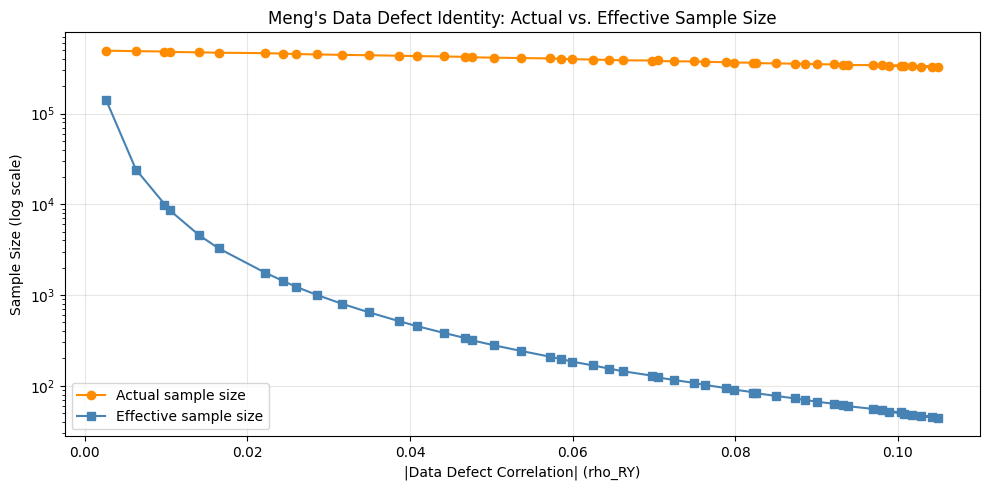

In [17]:
# GIVEN — run as-is
# Step 13: Compare effective sample sizes across bias levels

bias_strengths = np.linspace(0.002, 0.10, 50)
eff_sizes = []

for strength in bias_strengths:
    # Step 10's online poll, with the age effect on responding set to `strength`
    resp_prob_sim = 1 / (1 + np.exp(strength * (age - 35)))
    resp_sim = rng.random(N) < resp_prob_sim
    n_sim = resp_sim.sum()

    rho_sim = np.corrcoef(resp_sim.astype(float), Y)[0, 1]
    f_sim = n_sim / N
    n_eff_sim = f_sim / (rho_sim**2 * (1 - f_sim))
    eff_sizes.append((abs(rho_sim), n_sim, n_eff_sim))

# Each tuple in the list becomes one row
eff_df = pd.DataFrame(eff_sizes, columns=['abs_rho', 'n_actual', 'n_effective'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(eff_df['abs_rho'], eff_df['n_actual'], 'o-', color='darkorange',
            label='Actual sample size')
ax.semilogy(eff_df['abs_rho'], eff_df['n_effective'], 's-', color='steelblue',
            label='Effective sample size')
ax.set_xlabel('|Data Defect Correlation| (rho_RY)')
ax.set_ylabel('Sample Size (log scale)')
ax.set_title("Meng's Data Defect Identity: Actual vs. Effective Sample Size")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Extension Interpretation

1. At what level of $|\rho_{R,Y}|$ does the effective sample size drop below 1,000? Below 100?
2. The 2016 CCES had $\rho_{R,Y} \approx -0.005$ and $N \approx 231$ million eligible voters. Compute the effective sample size. Does this match Meng's claim that 2.3M responses were worth ~400 random ones?
3. **Practical implication:** You are a data scientist at a polling firm. Your client says: "We have a panel of 500,000 online respondents. Why do we need a probability sample?" Write a 2-3 sentence response using the effective sample size concept.

1. the effective sample size drops below 1,000 at about ∣ρR,Y ≈0.03 and below 100 at about ∣ρR,Y∣ ≈0.10
2. When using Meng's formula with f=n/N and p=-0.005, the effective sample size comes out to be about 40,000 randon observations. This means the 2.3 million repsonses would not be equivalent to 400 random observation. Instead the 400 comes from a specific CCES calculation in Meng's example.
3. A panel of 50,000 respondents will have a much smaller effective sample size if participation is related to certain outcomes. A probabilty sample will help reduce the selection bias, so the effective sample size can be much closer to the actual number of observations.